In [1]:
# Run in case you dont have awswrangler already installed!
# !pip install awswrangler

In [2]:
import pandas as pd
import boto3
import awswrangler as wr

In [3]:
df = pd.read_csv("diabetic_data.csv")

print(df.shape)

df.head()

(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


Here below is where I create a TEMPORARY s3 bucket. This is temporary becuase we have 3 seperate aws accounts. So I figured that Divya can use this code to create her own (REAL) s3 account. This means she will have to be the owner of the infrastcture so after she creates her model, anything we do after, we have to send her the code to run using her S3 account in order for it to work.

In [4]:
# config
BUCKET_NAME = "aai540-divya-diabetes-mlops" 
REGION = "us-east-1"

import boto3
# s3 client
s3_client = boto3.client("s3", region_name=REGION)

# bucket
try:
    if REGION == "us-east-1":
        s3_client.create_bucket(Bucket=BUCKET_NAME)
    else:
        s3_client.create_bucket(
            Bucket=BUCKET_NAME,
            CreateBucketConfiguration={
                "LocationConstraint": REGION
            }
        )

    print(f"Bucket '{BUCKET_NAME}' created successfully!")

except Exception as e:
    print("Error creating bucket:")
    print(e)

Bucket 'aai540-divya-diabetes-mlops' created successfully!


In [5]:
#create folders

folders = [
    "raw/diabetic_data/",
    "raw/mappings/"
]

for folder in folders:
    s3_client.put_object(
        Bucket=BUCKET_NAME,
        Key=folder
    )

print("New folders created!")

New folders created!


In [6]:
#upload files

# Upload main dataset
s3_client.upload_file(
    "diabetic_data.csv",
    BUCKET_NAME,
    "raw/diabetic_data/diabetic_data.csv"
)

# Upload mapping file
s3_client.upload_file(
    "IDS_mapping.csv",
    BUCKET_NAME,
    "raw/mappings/IDS_mapping.csv"
)

print("Files uploaded into separated folders!")

Files uploaded into separated folders!


In [7]:
#Create query

create_table_query = f"""
CREATE EXTERNAL TABLE IF NOT EXISTS diabetic_readmissions (
    encounter_id BIGINT,
    patient_nbr BIGINT,
    race STRING,
    gender STRING,
    age STRING,
    weight STRING,
    admission_type_id INT,
    discharge_disposition_id INT,
    admission_source_id INT,
    time_in_hospital INT,
    payer_code STRING,
    medical_specialty STRING,
    num_lab_procedures INT,
    num_procedures INT,
    num_medications INT,
    number_outpatient INT,
    number_emergency INT,
    number_inpatient INT,
    diag_1 STRING,
    diag_2 STRING,
    diag_3 STRING,
    number_diagnoses INT,
    max_glu_serum STRING,
    A1Cresult STRING,
    metformin STRING,
    insulin STRING,
    change STRING,
    diabetesMed STRING,
    readmitted STRING
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
WITH SERDEPROPERTIES (
    "separatorChar" = ",",
    "quoteChar" = "\\""
)
LOCATION 's3://{BUCKET_NAME}/raw/diabetic_data/'
TBLPROPERTIES ("skip.header.line.count"="1");
"""

In [8]:
#create athena table 
import boto3
import awswrangler as wr
import pandas as pd

BUCKET_NAME = "aai540-divya-diabetes-mlops"
REGION = "us-east-1"

DATABASE_NAME = "diabetes_readmission_db"

ATHENA_OUTPUT = f"s3://{BUCKET_NAME}/athena-results/"

wr.athena.start_query_execution(
    sql=create_table_query,
    database=DATABASE_NAME,
    s3_output=ATHENA_OUTPUT
)

print("Athena table recreated successfully!")

s3_client.put_object(
    Bucket=BUCKET_NAME,
    Key="athena-results/"
)

Athena table recreated successfully!


{'ResponseMetadata': {'RequestId': '68JYXJ1VJ2V6Q21V',
  'HostId': 'mlQgWUZDVSvkJ3ZgZ8piAkdQF+1EGJpQjdJigq0+amy8t+lpW58HXOxpojx8cPcVgB+p6I6An3xqWMYRqQAE/76q9OPQ+pGD',
  'HTTPStatusCode': 200,
  'HTTPHeaders': {'x-amz-id-2': 'mlQgWUZDVSvkJ3ZgZ8piAkdQF+1EGJpQjdJigq0+amy8t+lpW58HXOxpojx8cPcVgB+p6I6An3xqWMYRqQAE/76q9OPQ+pGD',
   'x-amz-request-id': '68JYXJ1VJ2V6Q21V',
   'date': 'Wed, 27 May 2026 07:16:36 GMT',
   'x-amz-server-side-encryption': 'AES256',
   'etag': '"d41d8cd98f00b204e9800998ecf8427e"',
   'x-amz-checksum-crc32': 'AAAAAA==',
   'x-amz-checksum-type': 'FULL_OBJECT',
   'content-length': '0',
   'server': 'AmazonS3'},
  'RetryAttempts': 0},
 'ETag': '"d41d8cd98f00b204e9800998ecf8427e"',
 'ChecksumCRC32': 'AAAAAA==',
 'ChecksumType': 'FULL_OBJECT',
 'ServerSideEncryption': 'AES256'}

In [9]:
#Create Database Table 
import boto3
import awswrangler as wr
import pandas as pd

BUCKET_NAME = "aai540-divya-diabetes-mlops"
REGION = "us-east-1"
DATABASE_NAME = "diabetes_readmission_db"
ATHENA_OUTPUT = f"s3://{BUCKET_NAME}/athena-results/"

s3_client = boto3.client("s3", region_name=REGION)
glue_client = boto3.client("glue", region_name=REGION)

# Create Athena results folder
s3_client.put_object(Bucket=BUCKET_NAME, Key="athena-results/")

# Create Glue/Athena database if it does not exist
try:
    glue_client.create_database(
        DatabaseInput={"Name": DATABASE_NAME}
    )
    print(f"Database {DATABASE_NAME} created.")
except glue_client.exceptions.AlreadyExistsException:
    print(f"Database {DATABASE_NAME} already exists.")

Database diabetes_readmission_db already exists.


In [10]:
#Create Athena Table 
abscreate_table_query = f"""
CREATE EXTERNAL TABLE IF NOT EXISTS {DATABASE_NAME}.diabetic_readmissions (
    encounter_id BIGINT,
    patient_nbr BIGINT,
    race STRING,
    gender STRING,
    age STRING,
    weight STRING,
    admission_type_id INT,
    discharge_disposition_id INT,
    admission_source_id INT,
    time_in_hospital INT,
    payer_code STRING,
    medical_specialty STRING,
    num_lab_procedures INT,
    num_procedures INT,
    num_medications INT,
    number_outpatient INT,
    number_emergency INT,
    number_inpatient INT,
    diag_1 STRING,
    diag_2 STRING,
    diag_3 STRING,
    number_diagnoses INT,
    max_glu_serum STRING,
    A1Cresult STRING,
    metformin STRING,
    repaglinide STRING,
    nateglinide STRING,
    chlorpropamide STRING,
    glimepiride STRING,
    acetohexamide STRING,
    glipizide STRING,
    glyburide STRING,
    tolbutamide STRING,
    pioglitazone STRING,
    rosiglitazone STRING,
    acarbose STRING,
    miglitol STRING,
    troglitazone STRING,
    tolazamide STRING,
    examide STRING,
    citoglipton STRING,
    insulin STRING,
    glyburide_metformin STRING,
    glipizide_metformin STRING,
    glimepiride_pioglitazone STRING,
    metformin_rosiglitazone STRING,
    metformin_pioglitazone STRING,
    change STRING,
    diabetesMed STRING,
    readmitted STRING
)
ROW FORMAT SERDE 'org.apache.hadoop.hive.serde2.OpenCSVSerde'
WITH SERDEPROPERTIES (
  "separatorChar" = ",",
  "quoteChar" = "\\"",
  "escapeChar" = "\\\\"
)
LOCATION 's3://{BUCKET_NAME}/raw/diabetic_data/'
TBLPROPERTIES ("skip.header.line.count"="1");
"""

wr.athena.start_query_execution(
    sql=create_table_query,
    database=DATABASE_NAME,
    s3_output=ATHENA_OUTPUT,
    wait=True
)

print("Athena table diabetic_readmissions created successfully!")

Athena table diabetic_readmissions created successfully!


In [11]:
#test query

query = """
SELECT *
FROM diabetic_readmissions
LIMIT 10
"""

results = wr.athena.read_sql_query(
    sql=query,
    database=DATABASE_NAME,
    s3_output=ATHENA_OUTPUT
)

results.head()

2026-05-27 07:16:41,666	WARNING services.py:2137 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 892317696 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=2.05gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.


2026-05-27 07:16:43,838	INFO worker.py:2007 -- Started a local Ray instance.


/opt/conda/lib/python3.12/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,diag_2,diag_3,number_diagnoses,max_glu_serum,a1cresult,metformin,insulin,change,diabetesmed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,?,?,1,None,None,No,No,No,No,No
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,250.01,255,9,None,None,No,No,No,No,No
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,250,V27,6,None,None,No,No,No,No,No
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,250.43,403,7,None,None,No,No,No,No,No
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,157,250,5,None,None,No,No,No,No,No


In [12]:
# I created this to help us see the athena table and the folder structure in a ui format


session = boto3.session.Session()
region = session.region_name

ACCOUNT_ID = boto3.client("sts").get_caller_identity()["Account"]

BUCKET_NAME = BUCKET_NAME
DATABASE_NAME = DATABASE_NAME

# S3 console link (bucket)
s3_console_url = f"https://s3.console.aws.amazon.com/s3/buckets/{BUCKET_NAME}?region={region}&tab=objects"

# Athena console link
athena_console_url = f"https://{region}.console.aws.amazon.com/athena/home?region={region}#query/editor"

print("S3 Bucket UI:", s3_console_url)
print("Athena UI:", athena_console_url)
print("Database:", DATABASE_NAME)

S3 Bucket UI: https://s3.console.aws.amazon.com/s3/buckets/aai540-divya-diabetes-mlops?region=us-east-1&tab=objects
Athena UI: https://us-east-1.console.aws.amazon.com/athena/home?region=us-east-1#query/editor
Database: diabetes_readmission_db


# Exploratory Data Analysis

In [13]:
query = """
SELECT *
FROM diabetic_readmissions
"""

df = wr.athena.read_sql_query(
    sql=query,
    database=DATABASE_NAME,
    s3_output=ATHENA_OUTPUT
)

print("Data loaded successfully!")
print(df.shape)

Data loaded successfully!
(101766, 29)


In [14]:
#df is from above with the diabetic data csv

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sort_values(ascending=False).head(10))

print("\nTarget distribution:")
print(df["readmitted"].value_counts(normalize=True))

df.head()

Shape: (101766, 29)

Missing values:
 encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
weight                      0
admission_type_id           0
discharge_disposition_id    0
admission_source_id         0
time_in_hospital            0
dtype: int64

Target distribution:
readmitted
No        0.948991
Steady     0.04589
Up        0.003213
Down      0.001906
Name: proportion, dtype: Float64


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,diag_2,diag_3,number_diagnoses,max_glu_serum,a1cresult,metformin,insulin,change,diabetesmed,readmitted
0,15789732,2785374,Caucasian,Female,[70-80),?,3,1,1,4,...,250,401,3,None,None,No,No,No,No,No
1,15790398,5426343,AfricanAmerican,Female,[80-90),?,3,2,1,6,...,402,425,9,None,None,No,No,No,No,No
2,15795438,36483633,Caucasian,Female,[80-90),?,1,1,7,3,...,486,491,8,None,None,No,No,No,No,No
3,15795666,57058956,Caucasian,Female,[90-100),?,6,11,7,2,...,599,276,6,None,None,No,No,No,No,No
4,15796284,14215743,Caucasian,Female,[50-60),?,3,1,1,4,...,621,614,6,None,None,No,No,No,No,No


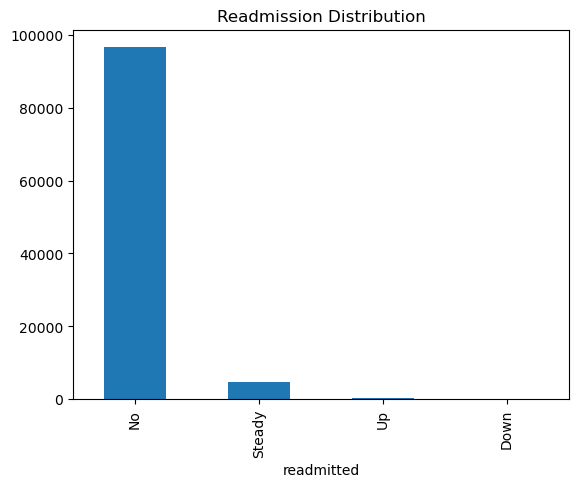

In [15]:
#quick distribution

import matplotlib.pyplot as plt

df["readmitted"].value_counts().plot(kind="bar")
plt.title("Readmission Distribution")
plt.show()

# FEEL FREE TO ADD MORE EDA (according to your background in bio)

In [16]:
#starts feature store
import os

feature_store_path = f"s3://{BUCKET_NAME}/feature-store/"
print("Feature Store Path:", feature_store_path)

Feature Store Path: s3://aai540-divya-diabetes-mlops/feature-store/


In [17]:
#set features 

features = [
    "race",
    "gender",
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "admission_source_id",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "max_glu_serum",
    "A1Cresult",
    "change",
    "diabetesMed",
    "insulin"
]

target = "readmitted"

In [18]:
# reload original clean data from Athena
df = pd.read_csv("diabetic_data.csv")

print(df["readmitted"].value_counts())

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [19]:
df["readmitted"] = df["readmitted"].replace({
    "NO": 0,
    "<30": 1,
    ">30": 0
}).astype(int)

target = "readmitted"

print(df["readmitted"].value_counts())

readmitted
0    90409
1    11357
Name: count, dtype: int64


/tmp/ipykernel_1207/1720716807.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["readmitted"] = df["readmitted"].replace({


In [20]:
# Separate features and target first

X = df[features].copy()
y = df[target].copy()

# One-hot encode ONLY feature columns
X = pd.get_dummies(X, drop_first=True)

# Add target column back
df_model = X.copy()
df_model[target] = y

print("Feature dataset shape:", df_model.shape)
print(df_model.head())

Feature dataset shape: (101766, 37)
   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
0                 1                  41               0                1   
1                 3                  59               0               18   
2                 2                  11               5               13   
3                 2                  44               1               16   
4                 1                  51               0                8   

   number_outpatient  number_emergency  number_inpatient  ...  \
0              

In [22]:
from sklearn.model_selection import train_test_split
import boto3

s3 = boto3.client("s3")

# Create splits again
train_val_test_df, production_df = train_test_split(
    df_model,
    test_size=0.4,
    random_state=42
)

train_df, temp_df = train_test_split(
    train_val_test_df,
    test_size=0.3333,
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))
print("Production:", len(production_df))

# Save locally
train_df.to_csv("/tmp/train.csv", index=False)
val_df.to_csv("/tmp/val.csv", index=False)
test_df.to_csv("/tmp/test.csv", index=False)
production_df.to_csv("/tmp/production.csv", index=False)

# Upload to S3
s3.upload_file("/tmp/train.csv", BUCKET_NAME, "processed/train.csv")
s3.upload_file("/tmp/val.csv", BUCKET_NAME, "processed/val.csv")
s3.upload_file("/tmp/test.csv", BUCKET_NAME, "processed/test.csv")
s3.upload_file("/tmp/production.csv", BUCKET_NAME, "processed/production.csv")

print("All datasets uploaded to S3 successfully!")

Train: 40708
Validation: 10175
Test: 10176
Production: 40707


All datasets uploaded to S3 successfully!


MODEL BUILDING and Training 

Baseline Model: Train using Logistic Regression Model 

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Split features and target

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_val = val_df.drop(columns=[target])
y_val = val_df[target]

# Train Logistic Regression baseline model

log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

log_model.fit(X_train, y_train)

# Predictions

y_pred = log_model.predict(X_val)
y_prob = log_model.predict_proba(X_val)[:, 1]

# Metrics

print("Logistic Regression Results")
print("--------------------------------")

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_prob))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred))

Logistic Regression Results
--------------------------------
Accuracy: 0.6622113022113022
Precision: 0.16321772078111338
Recall: 0.49733570159857904
F1 Score: 0.2457757296466974
ROC-AUC: 0.6326807256407634

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.68      0.78      9049
           1       0.16      0.50      0.25      1126

    accuracy                           0.66     10175
   macro avg       0.54      0.59      0.51     10175
weighted avg       0.83      0.66      0.72     10175



Interpretation of Logistic Regression Model Results

The balanced Logistic Regression model improved recall for high-risk readmission patients compared to the initial baseline model. Although the overall accuracy decreased due to handling the class imbalance, the updated model was better able to identify patients likely to be readmitted within 30 days.

The model achieved:

Accuracy: 66.2%
Recall: 49.7%
Precision: 16.3%
ROC-AUC: 0.63

The higher recall indicates that the model successfully identified nearly half of the actual readmission cases. While precision remains low, this tradeoff is often acceptable in healthcare prediction problems where identifying high-risk patients is more important than maximizing overall accuracy. Missing a patient who may be readmitted could have greater clinical consequences than generating additional false positive predictions.

Overall, the Logistic Regression model demonstrated reasonable performance for an imbalanced healthcare dataset, though further feature engineering and hyperparameter tuning could improve predictive capability.

TRAINING ON XGBoost Model

In [24]:
# Clean column names for XGBoost
X_train_xgb = X_train.copy()
X_val_xgb = X_val.copy()

X_train_xgb.columns = (
    X_train_xgb.columns
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "lt_", regex=False)
    .str.replace(">", "gt_", regex=False)
)

X_val_xgb.columns = X_train_xgb.columns

In [25]:
from xgboost import XGBClassifier

# Calculate imbalance ratio
scale_pos_weight = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

print("scale_pos_weight:", scale_pos_weight)

# Improved XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss"
)

# Train
xgb_model.fit(X_train_xgb, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_val_xgb)
y_prob_xgb = xgb_model.predict_proba(X_val_xgb)[:, 1]

# Metrics
print("XGBoost Results")
print("--------------------------------")

print("Accuracy:", accuracy_score(y_val, y_pred_xgb))
print("Precision:", precision_score(y_val, y_pred_xgb))
print("Recall:", recall_score(y_val, y_pred_xgb))
print("F1 Score:", f1_score(y_val, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_xgb))

print("\nClassification Report:\n")
print(classification_report(y_val, y_pred_xgb))

scale_pos_weight: 7.956655665566557


XGBoost Results
--------------------------------
Accuracy: 0.6888452088452088
Precision: 0.1724470134874759
Recall: 0.4769094138543517
F1 Score: 0.25330188679245286
ROC-AUC: 0.6368131018274887

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.72      0.80      9049
           1       0.17      0.48      0.25      1126

    accuracy                           0.69     10175
   macro avg       0.54      0.60      0.53     10175
weighted avg       0.83      0.69      0.74     10175



Interpretation of XGBoost Model Results

The balanced XGBoost model handled the imbalanced dataset reasonably well and improved recall for identifying readmission cases.

The model achieved:

Accuracy: 68.9%
Recall: 47.7%s
Precision: 17.2%
ROC-AUC: 0.64

Although precision remains low, the model is able to identify nearly half of the actual readmission cases. In healthcare prediction problems, recall is often more important than overall accuracy because failing to identify high-risk patients may lead to missed interventions and poorer patient outcomes.

The results suggest that the model is prioritizing sensitivity to high-risk patients, even at the cost of generating more false positives. However, additional tuning and feature engineering may still be needed to improve overall predictive performance.

In [26]:
import joblib

# Save model locally
joblib.dump(xgb_model, "/tmp/xgboost_model.pkl")

# Upload to S3
s3.upload_file(
    "/tmp/xgboost_model.pkl",
    BUCKET_NAME,
    "models/xgboost_model.pkl"
)

print("Model saved and uploaded to S3!")

Model saved and uploaded to S3!


BATCH INFERENCE

In [27]:
X_prod = production_df.drop(columns=[target])

# Clean column names
X_prod.columns = (
    X_prod.columns
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "lt_", regex=False)
    .str.replace(">", "gt_", regex=False)
)

production_predictions = xgb_model.predict(X_prod)

print(production_predictions[:10])

[0 0 1 0 0 0 0 1 0 1]


Upload Predictions

In [28]:
production_df["prediction"] = production_predictions

production_df.to_csv("/tmp/production_predictions.csv", index=False)

s3.upload_file(
    "/tmp/production_predictions.csv",
    BUCKET_NAME,
    "batch-output/production_predictions.csv"
)

print("Batch predictions uploaded!")

production_df.head(20)

Batch predictions uploaded!


,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,max_glu_serum_Norm,A1Cresult_>8,A1Cresult_Norm,change_No,diabetesMed_Yes,insulin_No,insulin_Steady,insulin_Up,readmitted,prediction
35956,1,1,6,11,68,0,20,0,0,0,...,False,False,False,True,True,False,True,False,0,0
60927,1,1,1,1,20,0,7,0,0,0,...,False,False,False,True,True,True,False,False,0,0
79920,3,6,1,4,21,3,23,1,0,2,...,False,False,False,True,True,True,False,False,0,1
50078,2,1,1,12,28,0,19,0,0,1,...,False,False,False,True,True,True,False,False,0,0
44080,1,2,7,1,21,0,6,0,0,0,...,False,False,False,True,True,True,False,False,1,0
4727,3,1,1,7,42,2,27,0,0,0,...,False,False,False,False,True,True,False,False,0,0
29944,1,1,7,6,43,2,17,0,0,0,...,False,False,False,True,True,True,False,False,0,0
84575,1,6,7,5,55,0,20,1,1,0,...,False,True,False,False,True,False,False,True,0,1
59479,1,3,7,5,50,0,26,0,0,0,...,False,False,False,False,True,False,False,True,1,0
56742,1,6,7,7,61,0,6,0,0,1,...,False,False,True,True,False,True,False,False,0,1
